In [2]:
import numpy as np
import pandas as pd
import ezdxf

In [83]:
df1 = pd.read_csv(r'F:\P-52403 Gorai\Gorai Design Update from BWDB_Jul-2025\Talbaria Padma\Raw Data\Talbariya_Topo_by_Musfiqur_rahman.csv')
df1.head(20)

,Chainage,Distance,RL_mPWD,Remarks,Easting,Norting
0,15.72,0.0,12.89,NaN,NaN,NaN
1,15.72,5.0,12.81,NaN,NaN,NaN
2,15.72,10.0,12.78,NaN,NaN,NaN
3,15.72,15.0,12.83,NaN,NaN,NaN
4,15.72,20.0,12.87,NaN,NaN,NaN
5,15.72,21.5,12.09,NaN,NaN,NaN
6,15.72,25.0,10.00,NaN,NaN,NaN
7,15.72,27.0,9.89,NaN,NaN,NaN
8,15.72,30.0,8.98,NaN,NaN,NaN
9,15.72,34.0,8.35,WL,713034.0,2651482.0


In [84]:
df4 = pd.read_csv(r'F:\P-52403 Gorai\Gorai Design Update from BWDB_Jul-2025\Talbaria Padma\Raw Data\Topo_SOL_EOL.csv')
df4.head(20)

,Chainage,SOL_X,SOL_Y,EOL_X,EOL_Y,lenght
0,15.72,713034.0,2651482.0,713018.97,2651450.67,34.75
1,15.65,712937.0,2651515.0,712920.56,2651476.70,41.68
2,15.55,712844.0,2651547.0,712833.92,2651516.69,31.94
3,15.45,712746.0,2651573.0,712734.82,2651539.62,35.21
4,15.35,712652.0,2651592.0,712640.37,2651560.47,33.61
5,15.25,712555.0,2651630.0,712542.82,2651597.70,34.52
6,15.15,712460.0,2651657.0,712450.75,2651621.68,36.52
7,15.05,712364.0,2651682.0,712353.80,2651649.19,34.36
8,14.95,712270.0,2651697.0,712263.94,2651670.67,27.02
9,14.85,712157.0,2651716.0,712147.61,2651665.17,51.69


In [85]:
# Build lookup dictionary from df4
coord_map = df4.set_index("Chainage")[["EOL_X", "EOL_Y"]].to_dict("index")

# Update df1 only where Distance == 0
df1.loc[df1["Distance"] == 0, ["Easting", "Norting"]] = (
    df1.loc[df1["Distance"] == 0, "Chainage"]
       .map(lambda x: coord_map.get(x, {"EOL_X": None, "EOL_Y": None}))
       .apply(pd.Series)
       .rename(columns={"EOL_X": "Easting", "EOL_Y": "Norting"})
       .values
)


In [86]:
import pandas as pd
import numpy as np

# Make new columns
df1["Easting_2"] = np.nan
df1["Norting_2"] = np.nan

# Process each Chainage separately
for ch, group in df1.groupby("Chainage"):
    # Start and end points for interpolation
    try:
        start_row = group[group["Distance"] == 0].iloc[0]
        end_row   = group[group["Remarks"] == "WL"].iloc[0]
    except IndexError:
        continue  # skip if start or WL missing

    start_dist = start_row["Distance"]
    end_dist   = end_row["Distance"]

    start_x, start_y = start_row["Easting"], start_row["Norting"]
    end_x, end_y     = end_row["Easting"], end_row["Norting"]

    # Interpolate each row
    for idx, row in group.iterrows():
        d = row["Distance"]
        t = (d - start_dist) / (end_dist - start_dist)  # param 0..1
        df1.at[idx, "Easting_2"] = start_x + t * (end_x - start_x)
        df1.at[idx, "Norting_2"] = start_y + t * (end_y - start_y)


In [88]:
import numpy as np

# Initialize new column
df1["dist_2"] = np.nan

# Process each Chainage separately
for ch, group in df1.groupby("Chainage"):
    # Sort by Distance just in case
    group = group.sort_values("Distance")
    dist_list = [0.0]  # start cumulative distance

    coords = list(zip(group["Easting_2"], group["Norting_2"]))

    # Compute cumulative distance
    for i in range(1, len(coords)):
        x0, y0 = coords[i-1]
        x1, y1 = coords[i]
        if np.nan in [x0, y0, x1, y1]:
            dist_list.append(np.nan)
        else:
            d = np.hypot(x1 - x0, y1 - y0)
            dist_list.append(dist_list[-1] + d)

    # Assign back to df
    df1.loc[group.index, "dist_2"] = dist_list


In [89]:
df1.head(50)

,Chainage,Distance,RL_mPWD,Remarks,Easting,Norting,Easting_2,Norting_2,dist_2
0,15.72,0.0,12.89,NaN,713018.97,2651450.67,713018.970000,2.651451e+06,0.000000
1,15.72,5.0,12.81,NaN,NaN,NaN,713021.180294,2.651455e+06,5.110098
2,15.72,10.0,12.78,NaN,NaN,NaN,713023.390588,2.651460e+06,10.220196
3,15.72,15.0,12.83,NaN,NaN,NaN,713025.600882,2.651464e+06,15.330294
4,15.72,20.0,12.87,NaN,NaN,NaN,713027.811176,2.651469e+06,20.440392
5,15.72,21.5,12.09,NaN,NaN,NaN,713028.474265,2.651470e+06,21.973421
6,15.72,25.0,10.00,NaN,NaN,NaN,713030.021471,2.651474e+06,25.550490
7,15.72,27.0,9.89,NaN,NaN,NaN,713030.905588,2.651476e+06,27.594529
8,15.72,30.0,8.98,NaN,NaN,NaN,713032.231765,2.651478e+06,30.660588
9,15.72,34.0,8.35,WL,713034.00,2651482.00,713034.000000,2.651482e+06,34.748666


In [90]:
df1.to_csv(r'F:\P-52403 Gorai\Gorai Design Update from BWDB_Jul-2025\Talbaria Padma\Raw Data\Topo_withEasting_northing_f.csv')

# Grid X Y marge from X Y of Dfs file

In [ ]:
x = pd.read_csv('F:\P-52403 Gorai\Talbaria Padma\Model\Grid\X.csv')
x.head()

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\rbe\AppData\Local\Temp\ipykernel_17104\2318352171.py:1: SyntaxWarning: invalid escape sequence '\P'
  x = pd.read_csv('F:\P-52403 Gorai\Talbaria Padma\Model\Grid\X.csv')


,ID,0,1,2,3,4,5,6,7,8,...,561,562,563,564,565,566,567,568,569,570
0,219,402543.4,402573.0,402601.6,402629.9,402658.1,402686.0,402713.9,402741.7,402769.4,...,444709.5,444784.5,444859.5,444934.2,445008.5,445082.9,445155.0,445225.0,445298.4,445376.3
1,218,402529.6,402559.2,402587.9,402616.3,402644.4,402672.5,402700.4,402728.2,402755.9,...,444694.0,444769.1,444844.1,444918.9,444993.3,445067.7,445140.3,445211.4,445285.3,445362.9
2,217,402515.8,402545.4,402574.2,402602.6,402630.8,402658.9,402686.8,402714.7,402742.4,...,444678.4,444753.6,444828.7,444903.6,444978.1,445052.5,445125.6,445197.7,445272.1,445349.6
3,216,402501.9,402531.6,402560.4,402588.9,402617.2,402645.3,402673.3,402701.2,402729.0,...,444662.9,444738.2,444813.3,444888.3,444962.9,445037.4,445110.9,445183.9,445258.8,445336.2
4,215,402488.1,402517.8,402546.7,402575.3,402603.6,402631.8,402659.8,402687.7,402715.5,...,444647.4,444722.7,444797.9,444873.0,444947.8,445022.4,445096.3,445170.0,445245.3,445322.7


In [9]:
y = pd.read_csv('F:\P-52403 Gorai\Talbaria Padma\Model\Grid\Y.csv')
y.head()

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\rbe\AppData\Local\Temp\ipykernel_17104\2064520921.py:1: SyntaxWarning: invalid escape sequence '\P'
  y = pd.read_csv('F:\P-52403 Gorai\Talbaria Padma\Model\Grid\Y.csv')


,ID,0,1,2,3,4,5,6,7,8,...,561,562,563,564,565,566,567,568,569,570
0,219,665352.3,665238.4,665128.3,665019.5,664911.5,664804.1,664697.1,664590.4,664484.2,...,639885.1,639827.1,639769.2,639711.3,639654.0,639596.5,639539.2,639486.7,639438.1,639388.8
1,218,665348.2,665234.8,665124.8,665015.9,664907.9,664800.5,664693.6,664586.9,664480.6,...,639864.9,639807.0,639749.3,639691.4,639634.2,639577.0,639520.2,639467.4,639417.9,639368.0
2,217,665344.1,665231.2,665121.2,665012.4,664904.4,664797.0,664690.0,664583.4,664477.1,...,639844.9,639787.0,639729.3,639671.6,639614.4,639557.4,639501.2,639448.1,639397.7,639347.3
3,216,665339.9,665227.5,665117.6,665008.8,664900.8,664793.4,664686.5,664579.9,664473.6,...,639824.8,639766.9,639709.3,639651.8,639594.7,639537.9,639481.9,639428.6,639377.4,639326.5
4,215,665335.9,665223.8,665113.9,665005.3,664897.3,664789.9,664682.9,664576.4,664470.1,...,639804.6,639746.9,639689.3,639631.9,639574.9,639518.3,639462.6,639408.9,639357.2,639305.8


In [10]:
# Melt the dataframes to long format
x_long = x.melt(id_vars='ID', var_name='k', value_name='x')
y_long = y.melt(id_vars='ID', var_name='k', value_name='y')

# Merge x and y based on ID and column name (k)
merged_df = pd.merge(x_long, y_long, on=['ID', 'k'])

# Rename columns to match your desired output
merged_df = merged_df.rename(columns={'ID': 'j'})

# Reorder columns
merged_df = merged_df[['x', 'y', 'j', 'k']]

merged_df.head(20)


,x,y,j,k
0,402543.4,665352.3,219,0
1,402529.6,665348.2,218,0
2,402515.8,665344.1,217,0
3,402501.9,665339.9,216,0
4,402488.1,665335.9,215,0
5,402474.3,665331.8,214,0
6,402460.5,665327.6,213,0
7,402446.7,665323.6,212,0
8,402432.8,665319.4,211,0
9,402419.0,665315.3,210,0


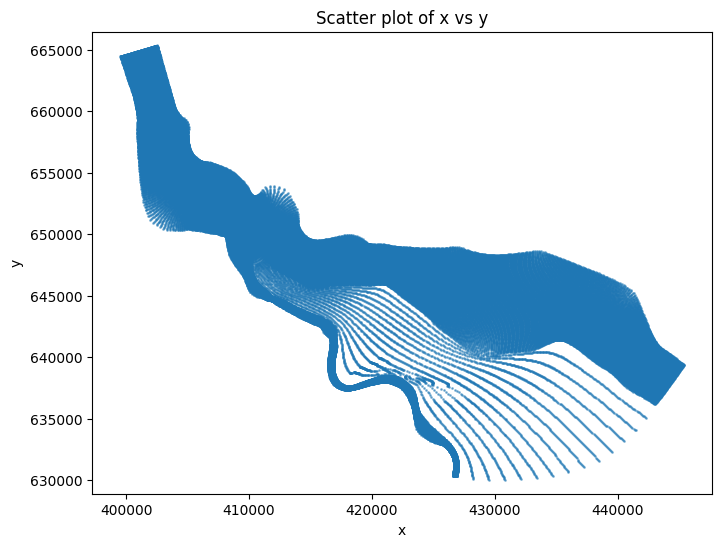

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(merged_df['x'], merged_df['y'], s=1, alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of x vs y')
plt.axis('equal')
plt.show()

In [12]:

merged_df.to_csv('F:\P-52403 Gorai\Talbaria Padma\Model\Grid\XY.csv')

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\rbe\AppData\Local\Temp\ipykernel_17104\1163506117.py:1: SyntaxWarning: invalid escape sequence '\P'
  merged_df.to_csv('F:\P-52403 Gorai\Talbaria Padma\Model\Grid\XY.csv')


# Max Cross Section Distance extract Gorai Kustai DPP

In [ ]:
import pandas as pd

file = r'F:\P-52403 Gorai\Talbaria Padma\Gorai Kustia DPP\XS_Gorai_DPP.csv'

# Use a Windows-friendly encoding
df = pd.read_csv(file, encoding="cp1252")   # or encoding="latin-1"
print(df.head(20))

In [ ]:
import pandas as pd

# Assuming df is already loaded
# Group by Zone_ID and Chainage, then get max Distance
df_max = (
    df.groupby(["Zone_ID", "Chainage"], as_index=False)["Distance"]
      .max()
      .rename(columns={"Distance": "Max_Distance"})
)

print(df_max.head(20))

file_2 = r'F:\P-52403 Gorai\Talbaria Padma\Gorai Kustia DPP\XS_len_Gorai_DPP.csv'

df_max.to_csv(file_2, encoding="cp1252")


    Zone_ID  Chainage  Max_Distance
0       1.0       0.0        199.29
1       1.0       0.1        199.28
2       1.0       0.2        197.62
3       1.0       0.3        248.13
4       1.0       0.4        269.38
5       1.0       0.5        300.01
6       1.0       0.6        300.11
7       1.0       0.7        299.11
8       1.0       0.8        299.47
9       1.0       0.9        299.47
10      1.0       1.0        299.24
11      1.0       1.1        299.24
12      1.0       1.2        300.77
13      1.0       1.3        298.51
14      1.1       0.0        248.91
15      1.1       0.1        248.91
16      1.1       0.2        249.21
17      1.1       0.3        246.91
18      1.1       0.4        250.00
19      1.1       0.5        248.81


# Generate Easting norting Along all point

In [53]:
import pandas as pd

file = r'F:\P-52403 Gorai\Talbaria Padma\Gorai Kustia DPP\XS_Gorai_DPP.csv'

# Use a Windows-friendly encoding
df1 = pd.read_csv(file, encoding="cp1252")   # or encoding="latin-1"
print(df1.head(20))


    Zone_ID  Chainage  Distance  RL_mPWD Remarks Easting Northing
0       1.0       0.1      0.00    15.12     NaN  714809  2650036
1       1.0       0.1     10.00    14.70     NaN     NaN      NaN
2       1.0       0.1     15.00    14.78     NaN     NaN      NaN
3       1.0       0.1     20.00    15.15     NaN     NaN      NaN
4       1.0       0.1     25.00    15.25     NaN     NaN      NaN
5       1.0       0.1     31.00    15.08     NaN     NaN      NaN
6       1.0       0.1     34.00    14.36     NaN     NaN      NaN
7       1.0       0.1     37.00    13.29     NaN     NaN      NaN
8       1.0       0.1     41.00    12.65     NaN     NaN      NaN
9       1.0       0.1     43.00    12.00     NaN     NaN      NaN
10      1.0       0.1     48.00    11.96     NaN     NaN      NaN
11      1.0       0.1     53.00    11.47      WL     NaN      NaN
12      1.0       0.1     55.00    11.00     NaN     NaN      NaN
13      1.0       0.1     57.00    10.86     NaN     NaN      NaN
14      1.

In [54]:
file2 = r'F:\P-52403 Gorai\Talbaria Padma\Gorai Kustia DPP\Runline_EOL_SOL.csv'
# Use a Windows-friendly encoding
df2 = pd.read_csv(file2, encoding="cp1252")   # or encoding="latin-1"
print(df2.head(20))

    Zone_ID  Chainage      SOL_X       SOL_Y      EOL_X       EOL_Y
0       1.1      0.50  714457.00  2650494.00  714617.09  2650685.90
1       1.1      0.40  714537.00  2650420.00  714694.60  2650611.68
2       1.1      0.30  714610.00  2650349.00  714767.40  2650539.34
3       1.1      0.20  714694.00  2650296.00  714846.79  2650493.31
4       1.1      0.10  714774.00  2650233.00  714942.61  2650416.27
5       1.1      0.00  714800.00  2650136.00  715023.41  2650244.35
6       1.0      0.10  714809.00  2650036.00  714998.70  2650098.56
7       1.0      0.20  714816.00  2649938.00  715012.12  2649978.18
8       1.0      0.30  714825.00  2649839.00  715071.75  2649863.76
9       1.0      0.40  714833.00  2649738.00  715101.94  2649745.62
10      1.0      0.50  714838.00  2649637.00  715137.72  2649642.38
11      1.0      0.60  714808.00  2649537.00  715109.40  2649541.75
12      1.0      0.70  714781.98  2649438.99  715081.07  2649443.36
13      1.0      0.80  714746.00  2649345.98  71

In [55]:
# make df3
df3 = df1.copy()
df3["X"] = None
df3["Y"] = None

# loop per (Zone_ID, Chainage) group
for (zone, ch), group in df1.groupby(["Zone_ID", "Chainage"]):
    match = df2[(df2["Zone_ID"] == zone) & (df2["Chainage"] == ch)]
    if match.empty:
        continue  # skip if no match in df2

    # Distance = 0 → SOL_X, SOL_Y
    idx0 = group[group["Distance"] == 0].index
    if not idx0.empty:
        df3.loc[idx0, "X"] = match["SOL_X"].values[0]
        df3.loc[idx0, "Y"] = match["SOL_Y"].values[0]

    # Distance = max → EOL_X, EOL_Y
    idxmax = group[group["Distance"] == group["Distance"].max()].index
    if not idxmax.empty:
        df3.loc[idxmax, "X"] = match["EOL_X"].values[0]
        df3.loc[idxmax, "Y"] = match["EOL_Y"].values[0]

df3.head(10)

,Zone_ID,Chainage,Distance,RL_mPWD,Remarks,Easting,Northing,X,Y
0,1.0,0.1,0.0,15.12,NaN,714809,2650036,714809.0,2650036.0
1,1.0,0.1,10.0,14.70,NaN,NaN,NaN,None,None
2,1.0,0.1,15.0,14.78,NaN,NaN,NaN,None,None
3,1.0,0.1,20.0,15.15,NaN,NaN,NaN,None,None
4,1.0,0.1,25.0,15.25,NaN,NaN,NaN,None,None
5,1.0,0.1,31.0,15.08,NaN,NaN,NaN,None,None
6,1.0,0.1,34.0,14.36,NaN,NaN,NaN,None,None
7,1.0,0.1,37.0,13.29,NaN,NaN,NaN,None,None
8,1.0,0.1,41.0,12.65,NaN,NaN,NaN,None,None
9,1.0,0.1,43.0,12.00,NaN,NaN,NaN,None,None


In [56]:
df4 = df3


import pandas as pd
import numpy as np
from scipy.interpolate import interp1d

# Make sure X and Y are numeric (None -> np.nan)
df4['X'] = pd.to_numeric(df4['X'], errors='coerce')
df4['Y'] = pd.to_numeric(df4['Y'], errors='coerce')

# Define interpolation function
def interpolate_xy(group):
    group = group.sort_values('Distance')
    
    # Only interpolate if at least 2 known points exist
    if group['X'].notna().sum() >= 2 and group['Y'].notna().sum() >= 2:
        # Interpolate X
        fx = interp1d(
            group.loc[group['X'].notna(), 'Distance'],
            group.loc[group['X'].notna(), 'X'],
            kind='linear',
            fill_value='extrapolate'
        )
        group['X'] = fx(group['Distance'])

        # Interpolate Y
        fy = interp1d(
            group.loc[group['Y'].notna(), 'Distance'],
            group.loc[group['Y'].notna(), 'Y'],
            kind='linear',
            fill_value='extrapolate'
        )
        group['Y'] = fy(group['Distance'])

    return group

# Apply to each (Zone_ID, Chainage) group
df4 = df4.groupby(['Zone_ID', 'Chainage'], group_keys=False).apply(interpolate_xy)

df4.head()

C:\Users\rbe\AppData\Local\Temp\ipykernel_14132\2530537685.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df4 = df4.groupby(['Zone_ID', 'Chainage'], group_keys=False).apply(interpolate_xy)


,Zone_ID,Chainage,Distance,RL_mPWD,Remarks,Easting,Northing,X,Y
0,1.0,0.1,0.0,15.12,NaN,714809,2650036,714809.000000,2.650036e+06
1,1.0,0.1,10.0,14.70,NaN,NaN,NaN,714818.519269,2.650039e+06
2,1.0,0.1,15.0,14.78,NaN,NaN,NaN,714823.278904,2.650041e+06
3,1.0,0.1,20.0,15.15,NaN,NaN,NaN,714828.038539,2.650042e+06
4,1.0,0.1,25.0,15.25,NaN,NaN,NaN,714832.798173,2.650044e+06


In [57]:
file = r'F:\P-52403 Gorai\Talbaria Padma\Gorai Kustia DPP\XS_Gorai_DPP_F0_1.csv'

# Use a Windows-friendly encoding
df4.to_csv(file, encoding="cp1252")   # or encoding="latin-1"

# XS Compare


In [ ]:
import pandas as pd 

df1 = pd.read_csv(r'F:\P-52403 Gorai\Talbaria Padma\XS_Compare\XS\July2025.csv')
df2 = pd.read_csv(r'F:\P-52403 Gorai\Talbaria Padma\XS_Compare\XS\October2022.csv')
df2.head(5)


,Chainage,Easting,Nortinh,RL,Distance
0,1.0,401401.56,653564.72,12.70,0.0
1,1.0,401404.16,653566.22,12.71,3.0
2,1.0,401406.76,653567.71,12.73,6.0
3,1.0,401409.36,653569.21,12.74,9.0
4,1.0,401411.96,653570.70,12.75,12.0


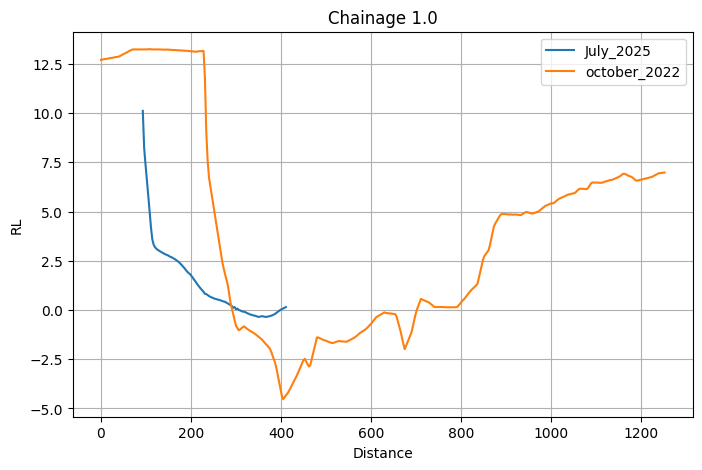

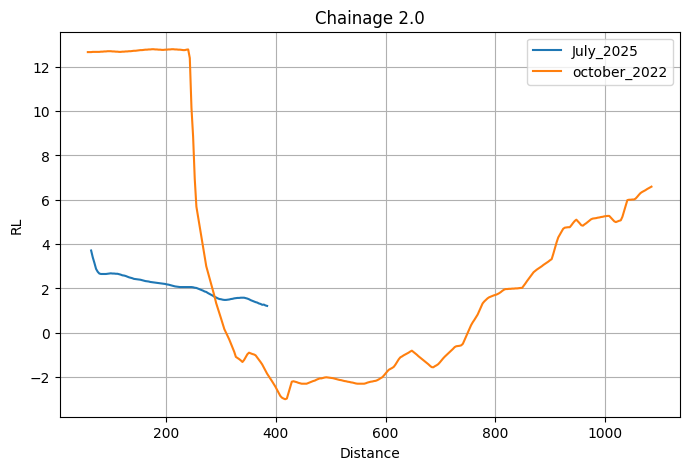

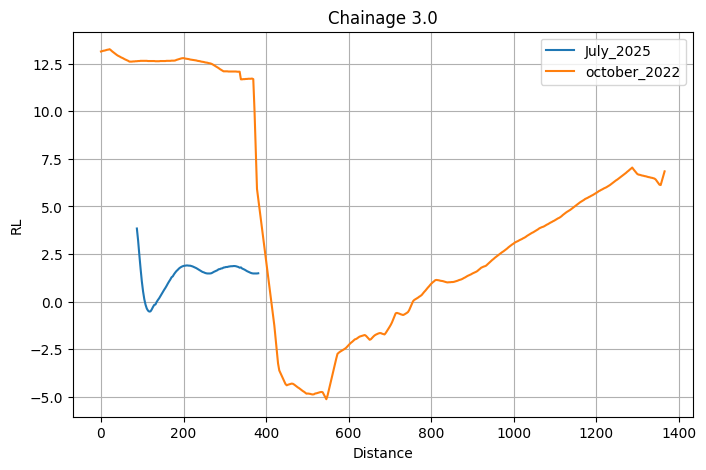

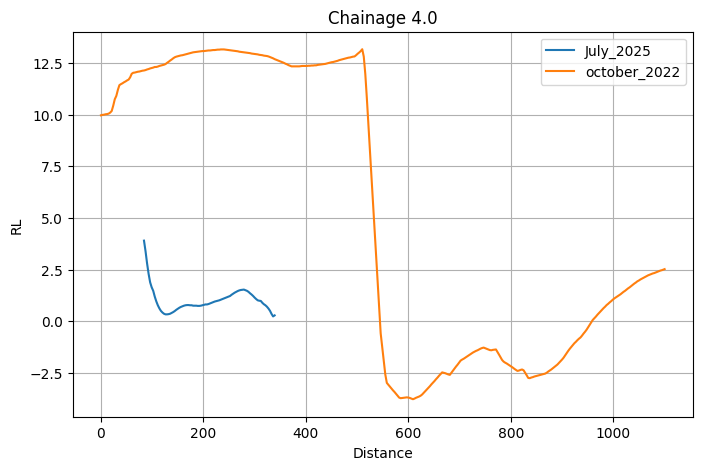

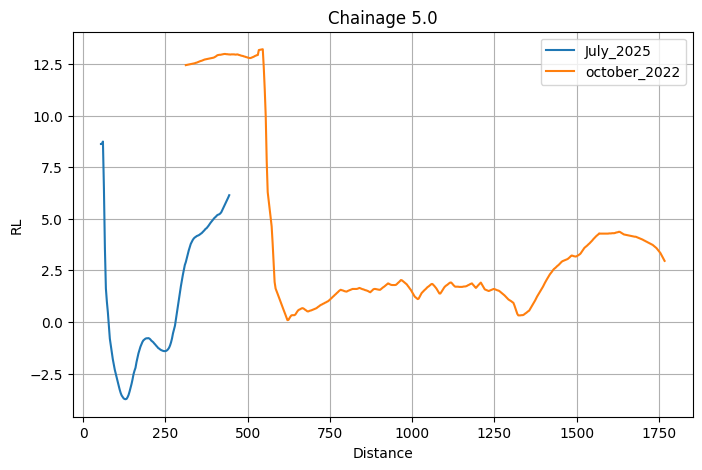

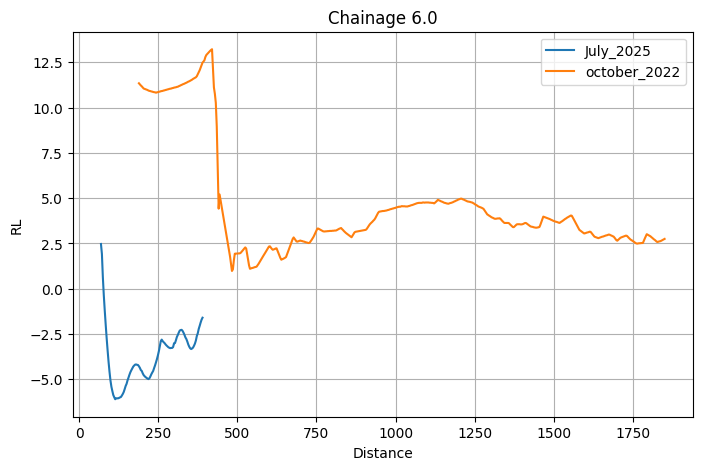

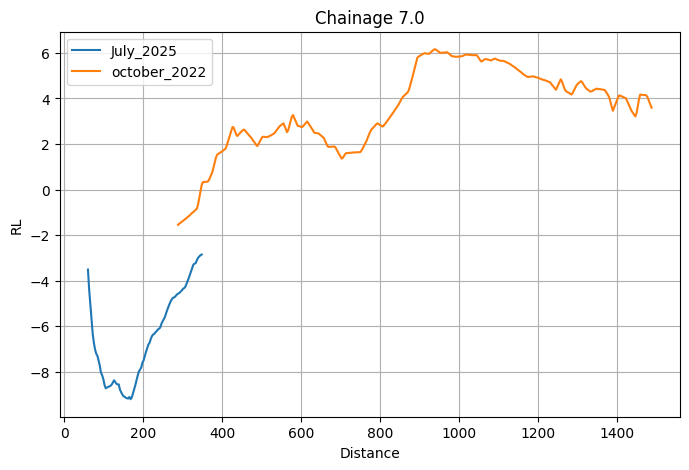

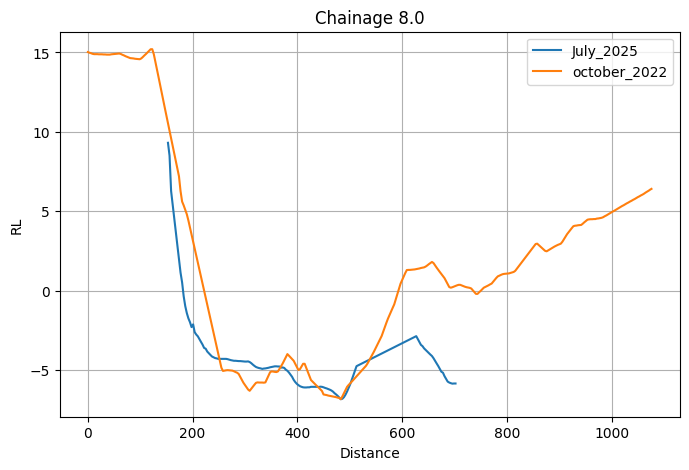

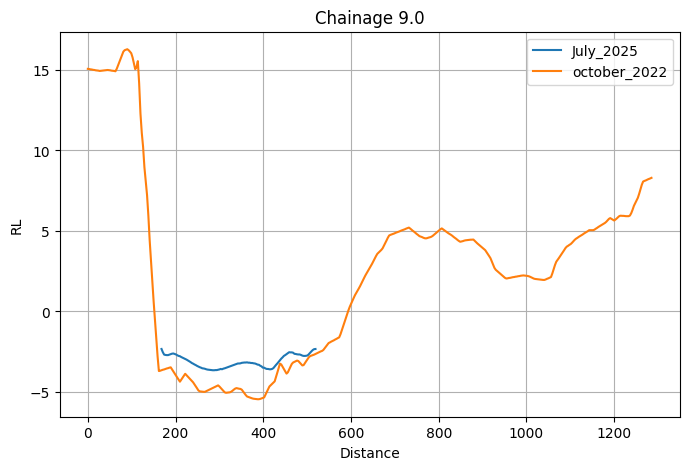

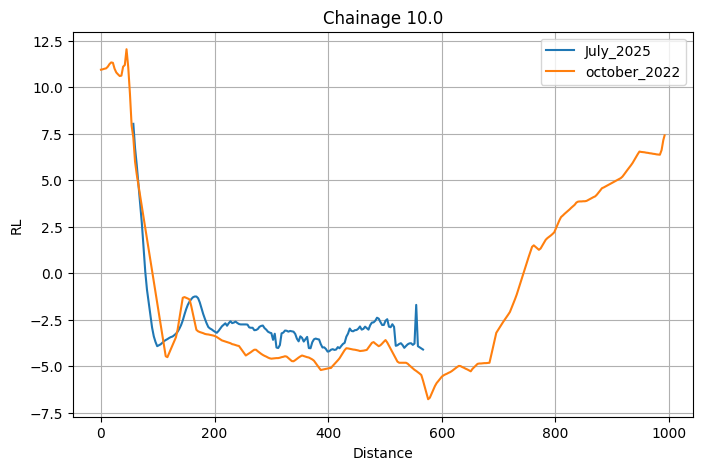

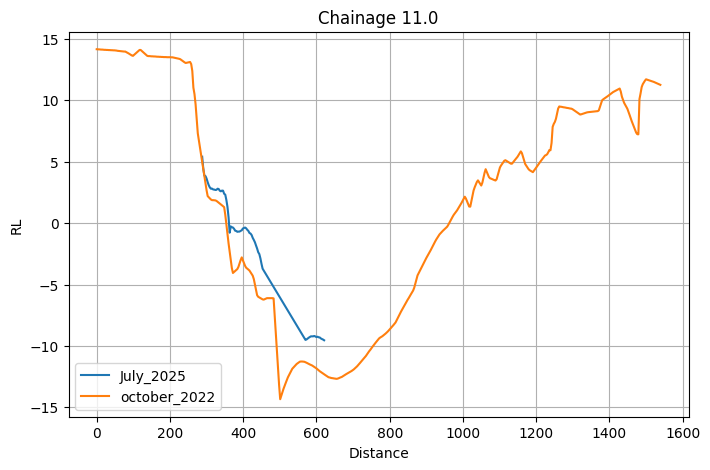

In [5]:
import matplotlib.pyplot as plt

chainages = sorted(set(df1['Chainage']).intersection(df2['Chainage']))

for ch in chainages:
    fig, ax = plt.subplots(figsize=(8, 5))
    d1 = df1[df1['Chainage'] == ch]
    d2 = df2[df2['Chainage'] == ch]
    ax.plot(d1['Distance'], d1['RL'], label='July_2025')
    ax.plot(d2['Distance'], d2['RL'], label='october_2022')
    ax.set_title(f'Chainage {ch}')
    ax.set_xlabel('Distance')
    ax.set_ylabel('RL')
    ax.legend()
    ax.grid(True)
    plt.show()